# Part A – Data Loading and Initial Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


The Bank Marketing dataset used in this project is the complete dataset stored in the bank-full.csv file. It contains information collected from direct marketing campaigns carried out by a Portuguese banking institution. The data describes bank clients, the way they were contacted, and information from previous marketing campaigns.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45211
Number of columns: 17


The complete dataset contains 45,211 rows and 17 columns. Each row represents a marketing campaign record associated with a bank client. It includes information about the client, the current contact, and previous marketing campaign activity. Sixteen columns are input features that describe the client, the contact process, and previous campaign activity. The remaining column, y, is the prediction target.

In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


The dataset includes client-related variables, such as age, job, marital status, education, account balance, and loan status. It also contains information about the current contact and previous marketing campaigns. The final column, y, records whether the client subscribed to a term deposit.

In [4]:
target_column = "y"

print("Target column:", target_column)
print("Target values:", df[target_column].unique())

Target column: y
Target values: ['no' 'yes']


The prediction target is the variable `y`. A value of `yes` means that the client subscribed to a term deposit, while a value of `no` means that the client did not subscribe. Therefore, this project is a binary classification problem.

In [5]:
target_column = "y"
input_features = df.drop(columns=[target_column])

numerical_columns = input_features.select_dtypes(include="number").columns.tolist()
categorical_columns = input_features.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numerical input features:")
print(numerical_columns)
print("Number of numerical input features:", len(numerical_columns))

print("\nCategorical input features:")
print(categorical_columns)
print("Number of categorical input features:", len(categorical_columns))

Numerical input features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Number of numerical input features: 7

Categorical input features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Number of categorical input features: 9


The dataset contains seven numerical input features: age, balance, day, duration, campaign, pdays, and previous. It also contains nine categorical input features: job, marital, education, default, housing, loan, contact, month, and poutcome. The target variable, y, is kept separate from the input features.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


The dataset contains both numerical and categorical variables. Seven columns are stored as integers and ten columns are stored as strings. All 17 columns contain 45,211 non-null values, so no missing values are detected at this stage.

In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


The dataset contains no missing values. All 17 columns have zero null values, so no missing-value treatment is required at this stage.

In [8]:
unknown_counts = (df == "unknown").sum()

print("Unknown values:")
print(unknown_counts[unknown_counts > 0])

Unknown values:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


The dataset contains "unknown" values in four categorical columns. The job column contains 288 unknown values, education contains 1,857, contact contains 13,020, and poutcome contains 36,959. These values are not missing values in the technical sense, but they represent unavailable or unspecified information and should be considered during preprocessing.

In [9]:
pdays_minus_one_count = (df["pdays"] == -1).sum()
pdays_minus_one_percentage = pdays_minus_one_count / len(df) * 100

print(f"Rows with pdays = -1: {pdays_minus_one_count:,}")
print(f"Percentage with pdays = -1: {pdays_minus_one_percentage:.2f}%")

Rows with pdays = -1: 36,954
Percentage with pdays = -1: 81.74%


The value -1 appears in the pdays column in 36,954 rows, representing 81.74% of the dataset. According to the dataset description, this value indicates that the client was not previously contacted during an earlier campaign. Therefore, it is a meaningful value rather than a missing value or a data-entry error.

In [10]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


The dataset contains no duplicate rows. Therefore, no duplicate records need to be removed at this stage.

In [11]:
print("Class distribution of y:")
print(df["y"].value_counts())

print("\nClass distribution percentages:")
print(df["y"].value_counts(normalize=True) * 100)

Class distribution of y:
y
no     39922
yes     5289
Name: count, dtype: int64

Class distribution percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


The target variable is imbalanced. Approximately 88.30% of the observations belong to the no class, while only 11.70% belong to the yes class. This imbalance should be taken into account during model training and evaluation.

## Part A – Analysis

1. Each row represents a marketing campaign record associated with a bank client. It includes information about the client, the current contact, and previous marketing campaign activity.

2. The prediction target is y, which indicates whether the client subscribed to a term deposit.

3. The target variable is imbalanced. Approximately 88.30% of the observations belong to the no class, while approximately 11.70% belong to the yes class.

4. The dataset contains seven numerical input features: age, balance, day, duration, campaign, pdays, and previous.

5. The dataset contains nine categorical input features: job, marital, education, default, housing, loan, contact, month, and poutcome. The target variable y is kept separate because it is the prediction target rather than an input feature.

6. No conventional missing values or duplicate rows were found. However, the columns job, education, contact, and poutcome contain unknown values. In addition, pdays = -1 appears in 36,954 rows, representing 81.74% of the dataset. According to the dataset description, this value indicates that the client was not previously contacted. Therefore, it is a meaningful value rather than a missing value or a data-entry error.

# Part B – Exploratory Data Analysis

The purpose of this section is to explore the main patterns in the Bank Marketing dataset before preprocessing and model training. The analysis includes summary statistics, categorical value counts, target class distribution, visualizations, and written insights based on the observed results.

In [12]:
numerical_summary = df[numerical_columns].describe().T.round(2)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


### Summary Statistics of Numerical Variables

The numerical variables show considerable variation across the dataset. The average client age is approximately 40.94 years, while the median age is 39 years. Half of the clients are between 33 and 48 years old.

The average account balance is approximately 1,362 euros, while the median is only 448 euros. This difference, together with the minimum balance of -8,019 euros and the maximum balance of 102,127 euros, suggests that the balance distribution is positively skewed and contains extreme values.

The median number of contacts made during the current campaign is two, although the maximum is 63 contacts. The median value of `pdays` is `-1`, which is consistent with the earlier finding that most clients had not been contacted during a previous campaign.

### Value Counts of Important Categorical Variables

The following tables present the frequency and percentage of the categories in the job, education, month, and previous campaign outcome variables.

In [13]:
categorical_variables = ["job", "education", "month", "poutcome"]

for column in categorical_variables:
    print(f"\nValue counts for {column}:")
    
    value_counts_table = pd.DataFrame({
        "Count": df[column].value_counts(),
        "Percentage": (
            df[column].value_counts(normalize=True) * 100
        ).round(2)
    })
    
    display(value_counts_table)


Value counts for job:


,Count,Percentage
job,,
blue-collar,9732,21.53
management,9458,20.92
technician,7597,16.80
admin.,5171,11.44
services,4154,9.19
retired,2264,5.01
self-employed,1579,3.49
entrepreneur,1487,3.29
unemployed,1303,2.88



Value counts for education:


,Count,Percentage
education,,
secondary,23202,51.32
tertiary,13301,29.42
primary,6851,15.15
unknown,1857,4.11



Value counts for month:


,Count,Percentage
month,,
may,13766,30.45
jul,6895,15.25
aug,6247,13.82
jun,5341,11.81
nov,3970,8.78
apr,2932,6.49
feb,2649,5.86
jan,1403,3.10
oct,738,1.63



Value counts for poutcome:


,Count,Percentage
poutcome,,
unknown,36959,81.75
failure,4901,10.84
other,1840,4.07
success,1511,3.34


The most common job categories are blue-collar, management, and technician, which represent 21.53%, 20.92%, and 16.80% of the dataset, respectively.

Secondary education is the most common education level and represents 51.32% of the observations, followed by tertiary education at 29.42%.

The campaign contacts are not distributed equally across the months. May contains the largest number of contacts, with 13,766 observations representing 30.45% of the dataset. In contrast, December contains only 214 observations, representing 0.47%.

The value `unknown` is the most common category in `poutcome` and appears in 81.75% of the observations. This is consistent with the earlier finding that most clients had not been contacted during a previous campaign.

### Visualization 1 – Target Class Distribution

The first visualization examines the distribution of the target variable `y`.

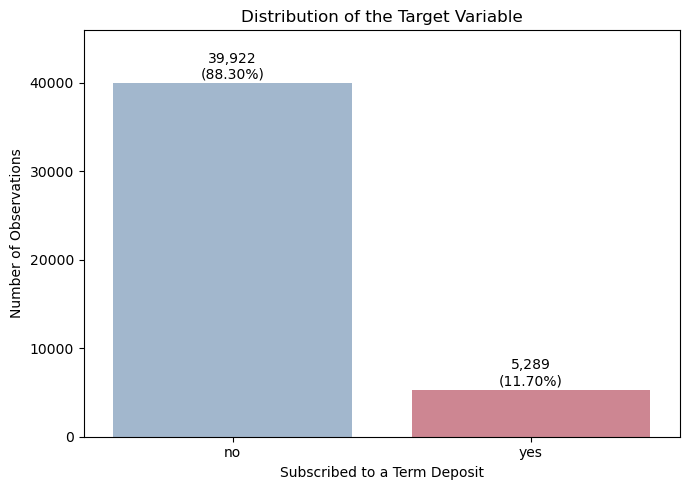

In [14]:
target_order = ["no", "yes"]

target_counts = df["y"].value_counts().reindex(target_order)
target_percentages = (
    df["y"].value_counts(normalize=True)
    .reindex(target_order) * 100
).round(2)

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="y",
    order=target_order,
    hue="y",
    palette={"no": "#9BB7D4", "yes": "#D97A8A"},
    legend=False
)

plt.title("Distribution of the Target Variable")
plt.xlabel("Subscribed to a Term Deposit")
plt.ylabel("Number of Observations")

for index, category in enumerate(target_order):
    count = target_counts.loc[category]
    percentage = target_percentages.loc[category]
    
    ax.text(
        index,
        count + 500,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center"
    )

plt.ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()

The target variable is clearly imbalanced. A total of 39,922 observations, representing 88.30% of the dataset, belong to the `no` class. Only 5,289 observations, representing 11.70%, belong to the `yes` class. This imbalance should be considered during model training and evaluation because the majority class is substantially larger than the minority class.

Because of this imbalance, accuracy alone may be misleading, since a model could achieve high accuracy mainly by predicting the majority class. Therefore, precision, recall, F1-score, and the confusion matrix should also be considered when evaluating the models.

### Visualization 2 – Age Distribution

The following histogram presents the distribution of client ages.

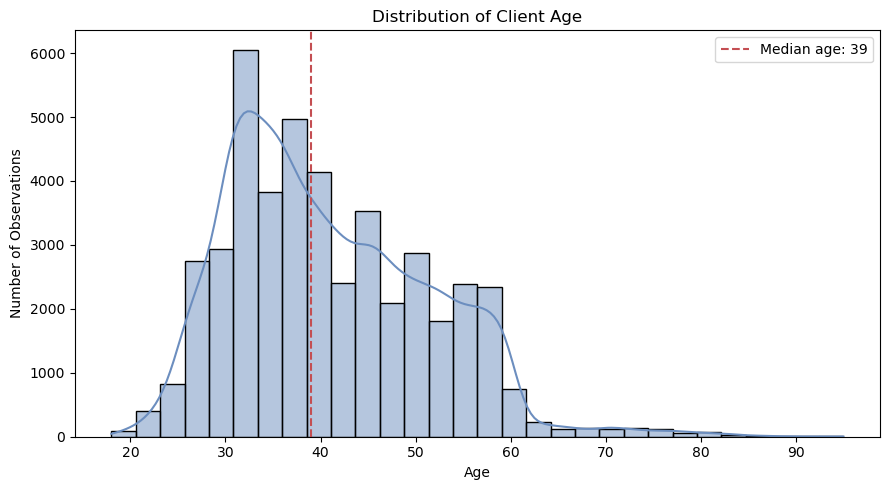

In [15]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="#6C8EBF"
)

plt.axvline(
    df["age"].median(),
    color="#C44E52",
    linestyle="--",
    label=f"Median age: {df['age'].median():.0f}"
)

plt.title("Distribution of Client Age")
plt.xlabel("Age")
plt.ylabel("Number of Observations")
plt.legend()
plt.tight_layout()
plt.show()

Most clients are concentrated in the adult age range, with a median age of 39 years. Half of the clients are between 33 and 48 years old. The distribution has a longer right tail because the dataset also contains a smaller number of considerably older clients, with ages reaching up to 95 years.

### Visualization 3 – Subscription Rate by Job Type

This visualization compares the percentage of clients who subscribed to a term deposit across the different job categories.

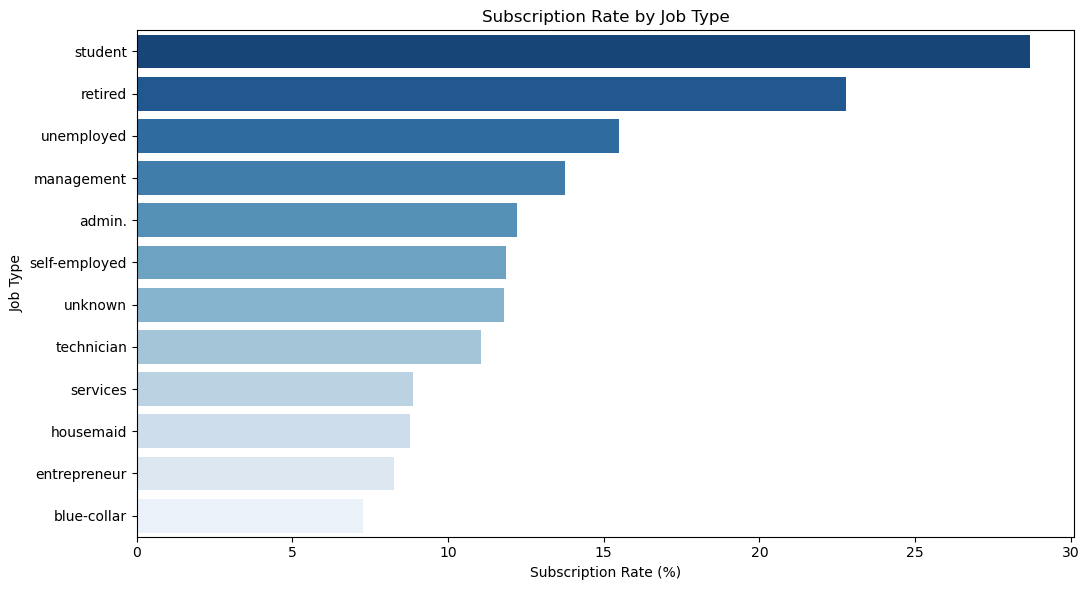

,job,Number_of_Clients,Subscription_Rate
8,student,938,28.68
5,retired,2264,22.79
10,unemployed,1303,15.50
4,management,9458,13.76
0,admin.,5171,12.20
6,self-employed,1579,11.84
11,unknown,288,11.81
9,technician,7597,11.06
7,services,4154,8.88
3,housemaid,1240,8.79


In [16]:
job_subscription = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("job", as_index=False)
      .agg(
          Number_of_Clients=("subscribed", "size"),
          Subscription_Rate=("subscribed", "mean")
      )
)

job_subscription["Subscription_Rate"] *= 100

job_subscription = job_subscription.sort_values(
    "Subscription_Rate",
    ascending=False
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=job_subscription,
    x="Subscription_Rate",
    y="job",
    hue="job",
    palette="Blues_r",
    legend=False
)

plt.title("Subscription Rate by Job Type")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()

display(job_subscription.round(2))

Subscription rates vary considerably across job categories. Students have the highest observed subscription rate at approximately 28.68%, followed by retired clients at approximately 22.79%. In contrast, blue-collar clients have the lowest observed subscription rate at approximately 7.27%.

However, these results should be interpreted together with the number of clients in each category. The student category contains only 938 clients, while the blue-collar category contains 9,732 clients. Therefore, a higher subscription rate does not necessarily indicate a larger total number of subscribers.

### Visualization 4 – Subscription Rate by Month

The following visualization examines whether the observed subscription rate differs across campaign months.

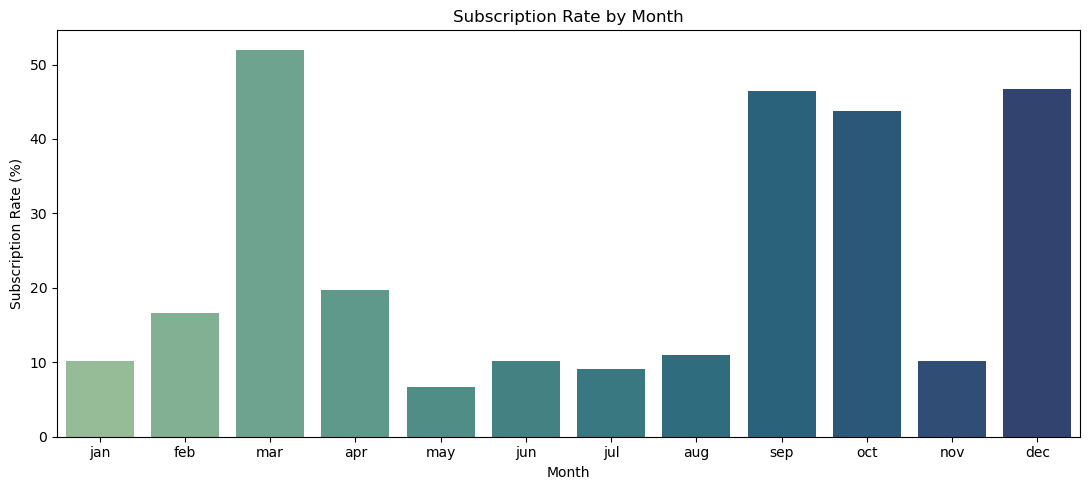

,month,Number_of_Clients,Subscription_Rate
4,jan,1403,10.12
3,feb,2649,16.65
7,mar,477,51.99
0,apr,2932,19.68
8,may,13766,6.72
6,jun,5341,10.22
5,jul,6895,9.09
1,aug,6247,11.01
11,sep,579,46.46
10,oct,738,43.77


In [17]:
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

month_subscription = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("month", as_index=False)
      .agg(
          Number_of_Clients=("subscribed", "size"),
          Subscription_Rate=("subscribed", "mean")
      )
)

month_subscription["Subscription_Rate"] *= 100

month_subscription["month"] = pd.Categorical(
    month_subscription["month"],
    categories=month_order,
    ordered=True
)

month_subscription = month_subscription.sort_values("month")

plt.figure(figsize=(11, 5))

sns.barplot(
    data=month_subscription,
    x="month",
    y="Subscription_Rate",
    hue="month",
    palette="crest",
    legend=False
)

plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.show()

display(month_subscription.round(2))

The highest observed subscription rate appears in March at approximately 51.99%. December, September, and October also have relatively high rates of 46.73%, 46.46%, and 43.77%, respectively.

However, these months contain considerably fewer campaign contacts than months such as May, July, and August. May contains the largest number of observations, with 13,766 contacts, but has the lowest subscription rate at approximately 6.72%. Therefore, the monthly subscription rates should be interpreted together with the number of observations and should not be treated as evidence that the month itself caused the differences.

### Visualization 5 – Subscription Rate by Previous Campaign Outcome

This visualization compares the current subscription rate according to the recorded outcome of the previous marketing campaign.

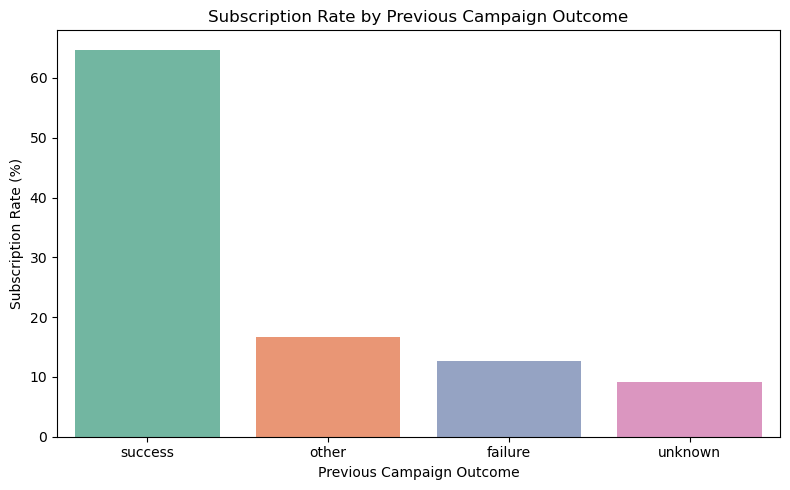

,poutcome,Number_of_Clients,Subscription_Rate
2,success,1511,64.73
1,other,1840,16.68
0,failure,4901,12.61
3,unknown,36959,9.16


In [18]:
poutcome_subscription = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("poutcome", as_index=False)
      .agg(
          Number_of_Clients=("subscribed", "size"),
          Subscription_Rate=("subscribed", "mean")
      )
)

poutcome_subscription["Subscription_Rate"] *= 100

poutcome_subscription = poutcome_subscription.sort_values(
    "Subscription_Rate",
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=poutcome_subscription,
    x="poutcome",
    y="Subscription_Rate",
    hue="poutcome",
    palette="Set2",
    legend=False
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.show()

display(poutcome_subscription.round(2))

Clients whose previous campaign outcome was recorded as `success` have a substantially higher current subscription rate of approximately 64.73%. The observed rates are considerably lower for `other`, `failure`, and `unknown` outcomes.

This result indicates a strong association between previous campaign success and current subscription behavior. However, most observations belong to the `unknown` category, so previous campaign information is not available for the majority of clients. The observed relationship should also be interpreted as an association rather than proof that previous success directly caused the current subscription.

## Part B – Main EDA Insights

1. **The target variable is imbalanced.** Approximately 88.30% of the observations belong to the `no` class, while only 11.70% belong to the `yes` class. This imbalance should be considered during model training and evaluation.

2. **Several numerical variables have wide ranges and extreme values.** For example, account balance ranges from -8,019 to 102,127 euros, while its median is only 448 euros. The number of campaign contacts reaches 63, although its median is only two contacts.

3. **Subscription rates differ across job categories.** Students and retired clients have the highest observed subscription rates, at approximately 28.68% and 22.79%, respectively. However, these categories contain fewer clients than larger groups such as blue-collar, management, and technician clients.

4. **Subscription rates vary considerably across campaign months.** March, December, September, and October have the highest observed rates, while May contains the largest number of contacts but has the lowest subscription rate. These comparisons should be interpreted carefully because the number of observations differs greatly between months.

5. **Previous campaign success is strongly associated with current subscription.** Clients with a successful previous campaign outcome have an observed subscription rate of approximately 64.73%. However, most clients have an `unknown` previous outcome, which limits the availability of this information.